## Introduction
In this notebook, I will start building the first baseline of a model, for this practice challenge. For this, I will use Linear Regression, as it is the more interpretable and simpler model for this case. I will use 2022-2023 for training, 2024 for validation and finally 2025 for testing.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

## Loading Data

In [2]:
laps = pd.read_pickle("../data/prepared_race_laps_2022_2025.pkl")

display(
    laps.groupby("Season").agg(
        Races=("RoundNumber", "nunique"),
        LapRecords=("LapNumber", "size"),
        EligiblePairs=("EligiblePair", "sum")
    )
)

print(f"Total eligible pairs: {laps['EligiblePair'].sum():,}")
laps_eligible = laps.loc[laps["EligiblePair"]].copy()

,Races,LapRecords,EligiblePairs
Season,,,
2022,22,23577,16971
2023,22,24420,18902
2024,24,26604,21394
2025,24,26689,20969


Total eligible pairs: 78,236


## Splitting Data by Years

In [3]:
train=laps_eligible[laps_eligible["Season"]<2024].copy()
validation=laps_eligible[laps_eligible["Season"]==2024].copy()

## Correlation Matrix

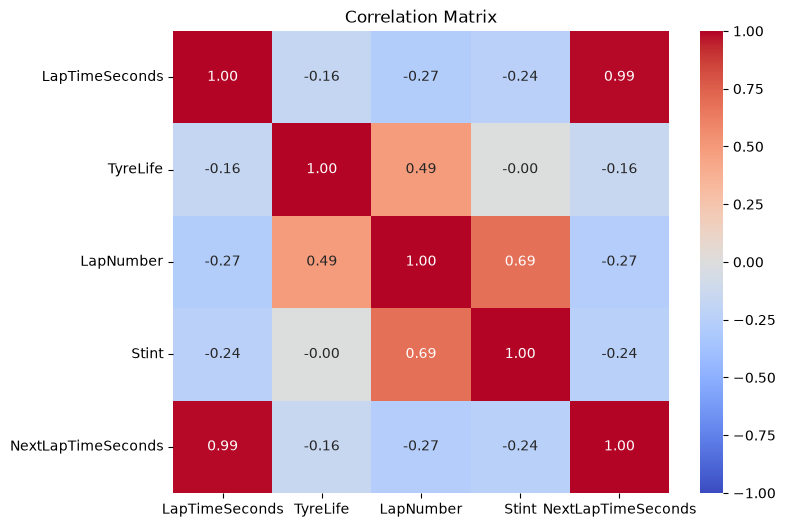

In [4]:
columns=["LapTimeSeconds",
        "TyreLife",
        "LapNumber",
        "Stint",
        "NextLapTimeSeconds"
]

correlation=train[columns].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Correlation Matrix")
plt.show()

The correlation between LapTimeSeconds and NextLapTimeSeconds is approximately 0.99, showing a strong positive linear relationship. This makes sense because consecutive laps belong to the same driver on the same circuit, usually under similar conditions. 

## Difference between LapTimeSeconds and NextLapTimeSeconds

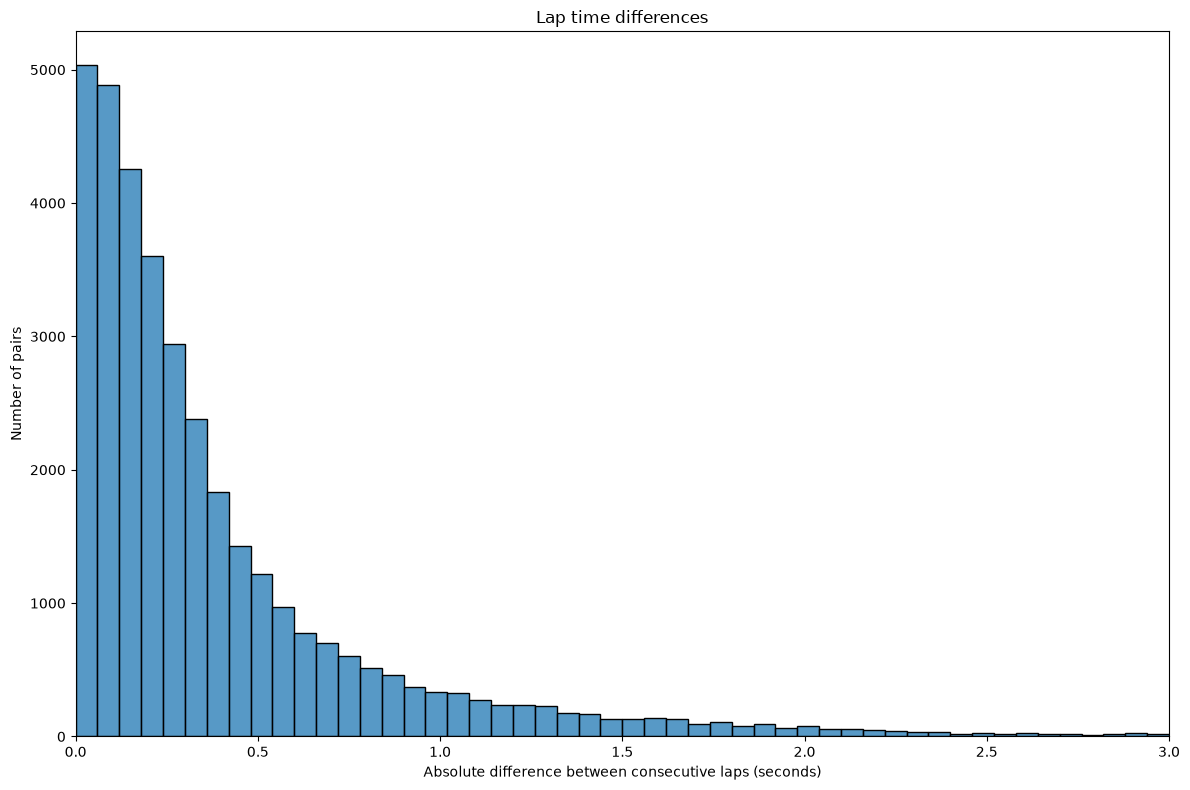

In [5]:
difference_laps=abs(train["LapTimeSeconds"] - train["NextLapTimeSeconds"])

plt.figure(figsize=(12,8))
sns.histplot(difference_laps, bins=50, binrange=(0, 3))
plt.xlim(0, 3)
plt.xlabel("Absolute difference between consecutive laps (seconds)")
plt.ylabel("Number of pairs")
plt.title("Lap time differences")
plt.tight_layout()
plt.show()


Small absolute differences are most common, especially below 0.5 seconds. Differences above 1.5 seconds account for approximately 5% of the eligible training pairs. This suggests that current lap time is a useful reference for predicting the next lap. The plot displays only differences up to 3 seconds; larger differences remain in the dataset. I will analyse the biggest differences as they are quite unusual in a normal F1 race.

In [6]:
largest_differences = difference_laps.nlargest(10)

display(
    train.loc[
        largest_differences.index,
        [
            "Season",
            "EventName",
            "Driver",
            "LapNumber",
            "LapTimeSeconds",
            "NextLapTimeSeconds"
        ]
    ].assign(DifferenceSeconds=largest_differences)
)

,Season,EventName,Driver,LapNumber,LapTimeSeconds,NextLapTimeSeconds,DifferenceSeconds
44750,2023,Mexico City Grand Prix,PIA,36.0,148.490,83.800,64.690
44608,2023,Mexico City Grand Prix,RUS,36.0,141.168,83.464,57.704
43969,2023,Mexico City Grand Prix,TSU,36.0,141.611,84.175,57.436
44789,2023,São Paulo Grand Prix,VER,4.0,132.670,75.745,56.925
44182,2023,Mexico City Grand Prix,HUL,36.0,138.655,84.022,54.633
45519,2023,São Paulo Grand Prix,NOR,4.0,130.857,76.231,54.626
9927,2022,British Grand Prix,LEC,3.0,149.193,94.650,54.543
9823,2022,British Grand Prix,PER,3.0,149.321,95.479,53.842
44395,2023,Mexico City Grand Prix,NOR,36.0,137.757,84.243,53.514
10279,2022,British Grand Prix,HAM,3.0,145.614,95.270,50.344


Some large differences come from restart laps that include time waiting on the grid. These laps can pass the track-status and timing checks despite not representing normal race pace. This is documented for Mexico 2023 in [FastF1 issue #473](https://github.com/theOehrly/Fast-F1/issues/473).

## Decision before modelling
I will keep these pairs for now, knowing that they might affect the model negatively, however I will look into these pairs again, after modelling and checking the model to see if I need to look into them.

## Linear Regression - Training

In [7]:
X_train=train[["LapTimeSeconds"]]
y_train=train["NextLapTimeSeconds"]

model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.98]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['LapTimeSeconds']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.713
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## Validation

In [8]:
X_validation=validation[["LapTimeSeconds"]]
y_validation=validation["NextLapTimeSeconds"]

predictions=model.predict(X_validation)

mae=mean_absolute_error(y_validation, predictions)
rmse=np.sqrt(mean_squared_error(y_validation, predictions))
r2=r2_score(y_validation,predictions)

print(f"MAE: {mae:.3f} seconds")
print(f"RMSE: {rmse:.3f} seconds")
print(f"R2: {r2:.3f}")

MAE: 0.505 seconds
RMSE: 1.055 seconds
R2: 0.989


As it is possible to see, the MAE is higher than I wanted, since it mean average error is outside of the 0-0.5 seconds frame and the RMSE is quite high for predicting a lap. The R2 looks quite good, close to 1.0, however I will now look more into detail on the insides of the model, make it less blackbox and understand what I can improve it on.

## Error table

In [9]:
errors=validation[
    ["EventName", "Driver", "LapNumber", "LapTimeSeconds", "NextLapTimeSeconds"]
].copy()

errors["Prediction"]=predictions
errors["Error"]=errors["NextLapTimeSeconds"]-errors["Prediction"]
errors["AbsoluteError"]=errors["Error"].abs()

display(errors.nlargest(10, "AbsoluteError").round(3))

,EventName,Driver,LapNumber,LapTimeSeconds,NextLapTimeSeconds,Prediction,Error,AbsoluteError
51829,Japanese Grand Prix,BOT,3.0,148.991,99.462,147.685,-48.223,48.223
51565,Japanese Grand Prix,OCO,3.0,140.237,99.541,139.108,-39.567,39.567
51080,Japanese Grand Prix,GAS,3.0,138.362,99.925,137.271,-37.346,37.346
51395,Japanese Grand Prix,MAG,3.0,132.996,100.103,132.014,-31.911,31.911
51343,Japanese Grand Prix,SAR,3.0,132.603,100.424,131.629,-31.205,31.205
51500,Japanese Grand Prix,ZHO,3.0,129.289,100.228,128.382,-28.154,28.154
60759,British Grand Prix,STR,18.0,95.789,107.568,95.561,12.007,12.007
60656,British Grand Prix,ALO,18.0,95.880,107.270,95.650,11.620,11.620
49676,Saudi Arabian Grand Prix,RIC,47.0,93.323,103.781,93.145,10.636,10.636
60870,British Grand Prix,MAG,25.0,95.150,105.466,94.935,10.531,10.531


## Baseline Comparison
The original baseline was supposed to get the time of lap t and use the same time to predict next lap. So in this cell I will analyse the MAE of both my model and that baseline and check whether if my model is useful or worse than the baseline.

In [10]:
errors["BaselineAbsoluteError"] = (
    errors["NextLapTimeSeconds"] - errors["LapTimeSeconds"]
).abs()

print(f"Baseline MAE: {errors['BaselineAbsoluteError'].mean():.3f} seconds")
print(f"Regression MAE: {errors['AbsoluteError'].mean():.3f} seconds")

Baseline MAE: 0.465 seconds
Regression MAE: 0.505 seconds


As it can be seen, the regression model is performing worse than the baseline, so this model does not improve a simple baseline.

## Comparing errors by race

In [11]:
race_errors=errors.groupby("EventName")[
    ["AbsoluteError", "BaselineAbsoluteError"]
].mean()

race_errors["Difference"]=(
    race_errors["AbsoluteError"]- race_errors["BaselineAbsoluteError"]
)

display(race_errors.sort_values("Difference", ascending=False).round(3))

,AbsoluteError,BaselineAbsoluteError,Difference
EventName,,,
Belgian Grand Prix,0.561,0.329,0.231
Chinese Grand Prix,0.480,0.308,0.173
Azerbaijan Grand Prix,0.600,0.433,0.168
Bahrain Grand Prix,0.422,0.313,0.110
Japanese Grand Prix,0.846,0.766,0.080
Singapore Grand Prix,0.527,0.449,0.078
Austrian Grand Prix,0.396,0.328,0.068
United States Grand Prix,0.472,0.404,0.068
Las Vegas Grand Prix,0.530,0.472,0.057


Regression is worse in 14 of the 24 races, especially in the Belgian Grand Prix, as the average time is 0.231 seconds higher than the baseline. The improvements are also quite small, so I will to analyse further on what to improve.

## Second model

In [12]:
features=["LapTimeSeconds","TyreLife", "LapNumber"]

X_train_multiple=train[features].copy()
X_validation_multiple=validation[features].copy()

median_tyre_life=X_train_multiple["TyreLife"].median()

X_train_multiple["TyreLife"]=(
    X_train_multiple["TyreLife"].fillna(median_tyre_life)
)

X_validation_multiple["TyreLife"]=(
    X_validation_multiple["TyreLife"].fillna(median_tyre_life)
)

In [17]:
multiple_model=LinearRegression()
multiple_model.fit(X_train_multiple, y_train)

multiple_predictions=multiple_model.predict(X_validation_multiple)

multiple_mae = mean_absolute_error(y_validation, multiple_predictions)
multiple_rmse=np.sqrt(mean_squared_error(y_validation, multiple_predictions))
multiple_r2=r2_score(y_validation, multiple_predictions)
print(f"Multiple regression MAE: {multiple_mae:.3f} seconds")
print(f"Multiple regression RMSE: {multiple_rmse:.3f} seconds")
print(f"Multiple regression R2: {multiple_r2:.3f} seconds")

print(f"Intercept: {multiple_model.intercept_:.4f}")
print(pd.Series(multiple_model.coef_, index=features).round(4))

Multiple regression MAE: 0.513 seconds
Multiple regression RMSE: 1.058 seconds
Multiple regression R2: 0.989 seconds
Intercept: 1.5481
LapTimeSeconds    0.9804
TyreLife          0.0109
LapNumber        -0.0016
dtype: float64


In [19]:
baseline_predictions = validation["LapTimeSeconds"]

comparison = pd.DataFrame({
    "Model": ["Same-lap baseline", "Simple regression", "Multiple regression"],
    "MAE (seconds)": [
        mean_absolute_error(y_validation, baseline_predictions),
        mae,
        multiple_mae
    ],
    "RMSE (seconds)": [
        np.sqrt(mean_squared_error(y_validation, baseline_predictions)),
        rmse,
        multiple_rmse
    ],
    "R²": [
        r2_score(y_validation, baseline_predictions),
        r2,
        multiple_r2
    ]
})

display(comparison.round(3))

,Model,MAE (seconds),RMSE (seconds),R²
0,Same-lap baseline,0.465,1.051,0.989
1,Simple regression,0.505,1.055,0.989
2,Multiple regression,0.513,1.058,0.989


## Conclusion
The same-lap-time baseline performed best on the 2024 validation data, with an MAE of 0.465 seconds. Simple regression achieved 0.505 seconds, while adding tyre age and lap number increased MAE to 0.513 seconds. The baseline also had the lowest RMSE. Therefore, the additional inputs did not improve this version of the model, despite the high R² values. I will next investigate how restart pairs affect training, while keeping the validation pairs unchanged for a fair comparison.